In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Load dataset
df = pd.read_csv("/content/sales_data.csv")

In [ ]:
# Convert Sale_Date to datetime
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])


 **Line Charts (Time Series Analysis)**

Why used:
Line charts are best for visualizing trends and changes over time.

Use case:


*   Daily sales trend
*   Monthly and quarterly growth patterns

**Axis formatting**:

*   X-axis: Date/Month/Quarter (rotated for readability)
*   Y-axis: Total Sales Amount (clearly labeled)



**Benefit**
:
They clearly show increases, decreases, and seasonality in sales.

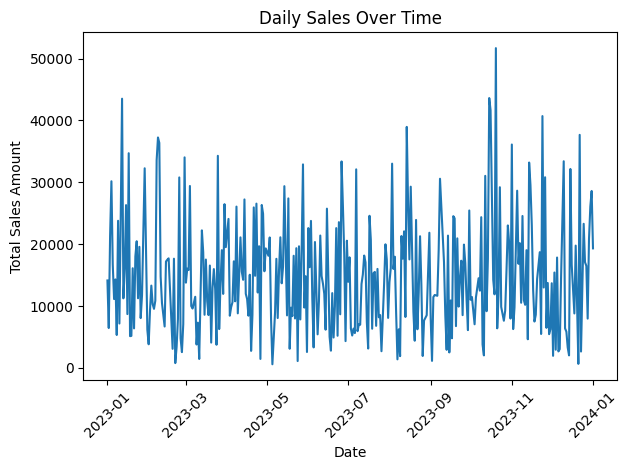

In [ ]:
# Daily Sales
daily_sales = df.groupby('Sale_Date')['Sales_Amount'].sum().reset_index()

plt.figure()
plt.plot(daily_sales['Sale_Date'], daily_sales['Sales_Amount'])
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

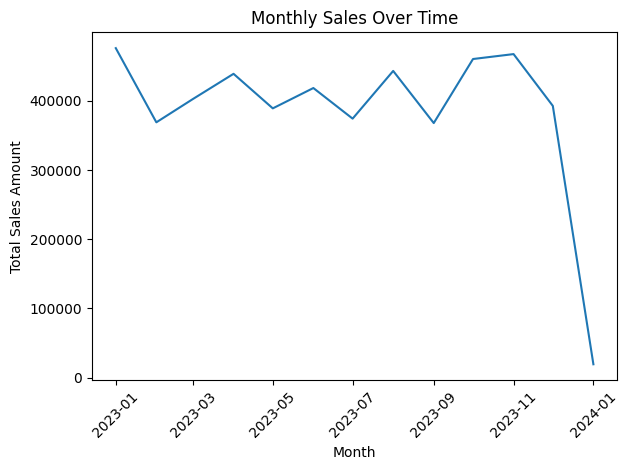

In [ ]:
# Monthly Aggregation
df['Year_Month'] = df['Sale_Date'].dt.to_period('M')
monthly_sales = df.groupby('Year_Month')['Sales_Amount'].sum().reset_index()
monthly_sales['Year_Month'] = monthly_sales['Year_Month'].dt.to_timestamp()

plt.figure()
plt.plot(monthly_sales['Year_Month'], monthly_sales['Sales_Amount'])
plt.title('Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


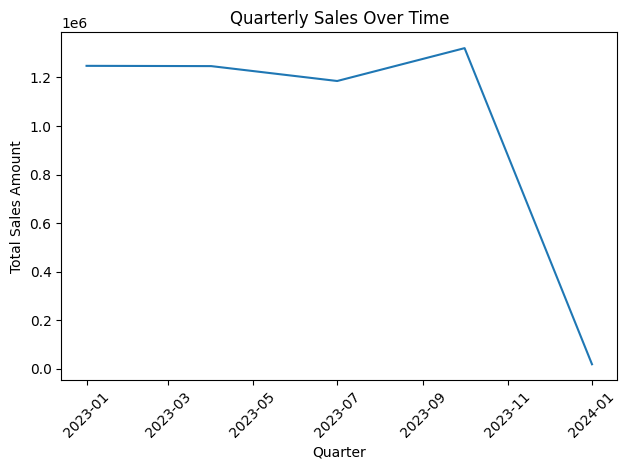

In [ ]:
# Quarterly Aggregation
df['Year_Quarter'] = df['Sale_Date'].dt.to_period('Q')
quarterly_sales = df.groupby('Year_Quarter')['Sales_Amount'].sum().reset_index()
quarterly_sales['Year_Quarter'] = quarterly_sales['Year_Quarter'].dt.to_timestamp()

plt.figure()
plt.plot(quarterly_sales['Year_Quarter'], quarterly_sales['Sales_Amount'])
plt.title('Quarterly Sales Over Time')
plt.xlabel('Quarter')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Bar Chart (Category Comparison)**

Why used:
Bar charts are ideal for comparing values across discrete categories.

Use case:


*   Comparing total sales among product categories

**Labels**:

*  X-axis: Product Category

*  Y-axis: Total Sales Amount

**Benefit**:
Makes it easy to identify the highest and lowest performing categories.

In [ ]:
category_sales = df.groupby('Product_Category')['Sales_Amount'].sum()

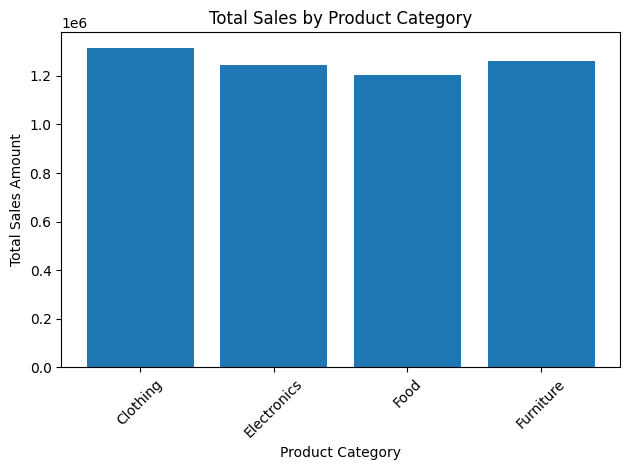

In [ ]:
# Bar Chart – Sales by Category
plt.figure()
plt.bar(category_sales.index, category_sales.values)
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Pie Chart (Share Analysis)**

Why used:
Pie charts effectively show proportional contribution.

Use case:

*   Understanding category share of total sales

**Formatting**:

*   autopct used to display percentages
*   Labels directly on slices for clarity

**Benefit**:
Quickly communicates which category dominates overall sales.

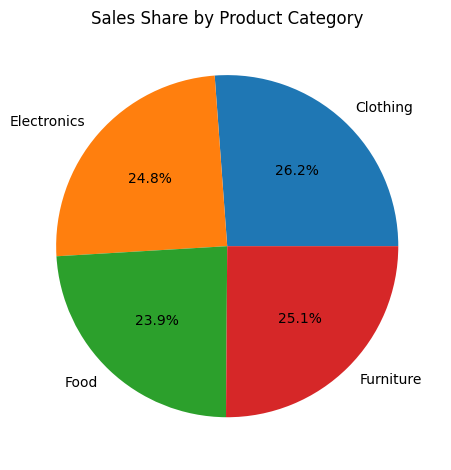

In [ ]:
# Pie Chart – Sales Share by Category
plt.figure()
plt.pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%')
plt.title("Sales Share by Product Category")
plt.tight_layout()
plt.show()

**Pandas Sales Analysis and Most common and important Data Cleaning Question**

In [2]:
# Data Manipulation
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [59]:
data = pd.read_csv('/content/superstore_sales.csv', encoding='latin1')

**DATA AUDIT**

You can’t make your data work for you until you know what data you’re talking about.
To get a quick idea of what the data looks like, we can call the head function on the data frame. By default, this returns the top five rows, but it can take in a parameter of how many rows to return.

In [60]:
data.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2.0,0.0,106.140,35.46,Medium,2011.0
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3.0,0.1,36.036,9.72,Medium,2011.0
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4.0,0.0,29.640,8.17,High,2011.0
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3.0,0.5,-26.055,4.82,High,2011.0
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5.0,0.1,37.770,4.70,Medium,2011.0


In [61]:
data.tail()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
39230,ES-2014-2818758,09-06-2014,09-06-2014,Same Day,Mary O'Rourke,Consumer,Provence-Alpes-Côte d'Azur,France,EU,Central,...,Office Supplies,Paper,"Xerox Cards & Envelopes, Premium",180,4.0,0.0,53.88,39.31,High,2014.0
39231,ES-2014-5916291,09-06-2014,12-06-2014,Second Class,Anthony Rawles,Corporate,Marche,Italy,EU,South,...,Office Supplies,Appliances,"Hamilton Beach Blender, Black",277,4.0,0.0,8.28,37.64,Medium,2014.0
39232,MX-2014-147487,09-06-2014,15-06-2014,Standard Class,Sarah Foster,Consumer,Sonsonate,El Salvador,LATAM,Central,...,Furniture,Chairs,"Hon Swivel Stool, Adjustable",332,3.0,0.0,96.36,37.09,Medium,2014.0
39233,MO-2014-4050,09-06-2014,12-06-2014,First Class,Rick Duston,Consumer,Meknès-Tafilalet,Morocco,Africa,Africa,...,Furniture,Furnishings,"Advantus Clock, Durable",194,4.0,0.0,11.52,36.88,High,2014.0
39234,IN-2014-42437,09-06-2014,13-06-2014,Standard Cla,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
data.shape

(39235, 21)

In [63]:
data.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39235 entries, 0 to 39234
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        39235 non-null  object 
 1   order_date      39235 non-null  object 
 2   ship_date       39235 non-null  object 
 3   ship_mode       39235 non-null  object 
 4   customer_name   39234 non-null  object 
 5   segment         39234 non-null  object 
 6   state           39234 non-null  object 
 7   country         39234 non-null  object 
 8   market          39234 non-null  object 
 9   region          39234 non-null  object 
 10  product_id      39234 non-null  object 
 11  category        39234 non-null  object 
 12  sub_category    39234 non-null  object 
 13  product_name    39234 non-null  object 
 14  sales           39234 non-null  object 
 15  quantity        39234 non-null  float64
 16  discount        39234 non-null  float64
 17  profit          39234 non-null 

In [65]:
# Checking missing values
data.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,1
segment,1
state,1
country,1
market,1
region,1


In [66]:
data = df.dropna()

In [67]:
data.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [68]:
# Generating descriptive statistics summary
data.describe().round()

,order_date,sales,quantity,discount,profit,shipping_cost,year
count,4688,4688.0,4688.0,4688.0,4688.0,4688.0,4688.0
mean,2011-05-19 12:48:50.375426560,160.0,3.0,0.0,12.0,18.0,2011.0
min,2011-01-01 00:00:00,1.0,1.0,0.0,-1218.0,0.0,2011.0
25%,2011-03-25 00:00:00,29.0,2.0,0.0,0.0,3.0,2011.0
50%,2011-05-31 00:00:00,77.0,3.0,0.0,8.0,7.0,2011.0
75%,2011-07-20 00:00:00,207.0,4.0,0.0,30.0,20.0,2011.0
max,2011-09-06 00:00:00,994.0,14.0,1.0,468.0,325.0,2011.0
std,NaN,199.0,2.0,0.0,85.0,29.0,0.0


**EXPLORATORY DATA ANALYSIS**

WHAT IS THE OVERALL SALES TREND?

In [69]:
data['order_date'].min()

Timestamp('2011-01-01 00:00:00')

In [70]:
data['order_date'].max()

Timestamp('2011-09-06 00:00:00')

In [71]:
data['month_year'] = data['order_date'].apply(lambda x: x.strftime('%Y-%m'))

/tmp/ipython-input-274/3296568142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['month_year'] = data['order_date'].apply(lambda x: x.strftime('%Y-%m'))


In [75]:
# grouping month_year by sales
data_temp = data.groupby('month_year')['sales'].sum().reset_index()

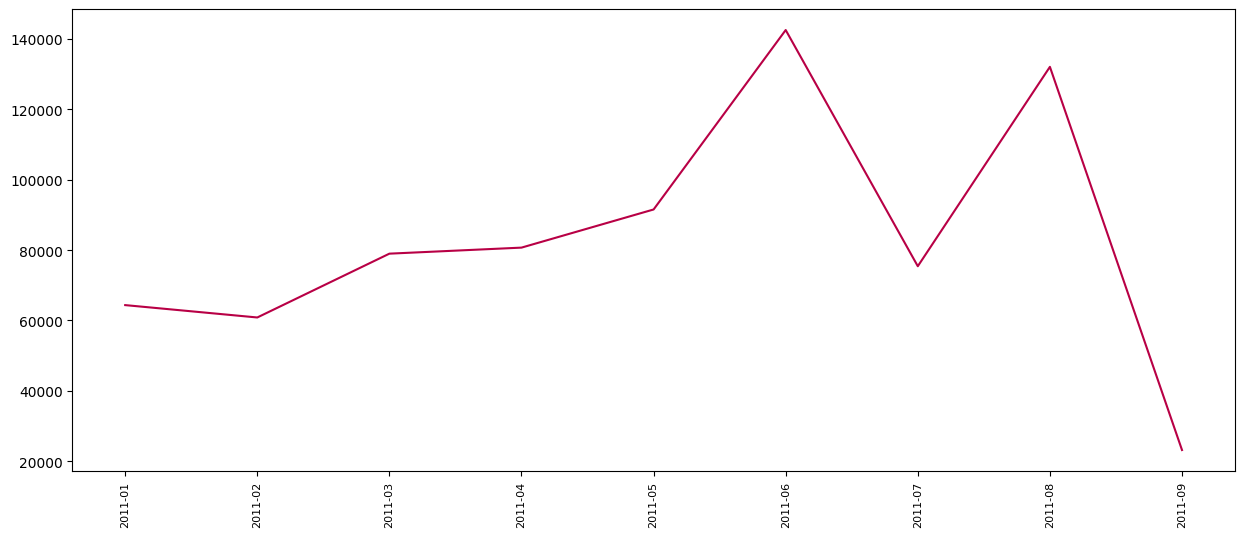

In [76]:
# Setting the figure size
plt.figure(figsize=(15, 6))
plt.plot(data_temp['month_year'], data_temp['sales'], color='#b80045')
plt.xticks(rotation='vertical', size=8)
plt.show()

WHICH ARE THE TOP 10 PRODUCTS BY SALES?

In [77]:
# Grouping products by sales
prod_sales = pd.DataFrame(data.groupby('product_name')['sales'].sum())

In [78]:
# Sorting the dataframe in descending order
prod_sales.sort_values(by=['sales'], inplace=True, ascending=False)

In [79]:
# Top 10 products by sales
prod_sales[:10]

,sales
product_name,
"Eldon File Cart, Single Width",3597.0
"Memorex Router, Erganomic",3221.0
"Cisco Signal Booster, with Caller ID",3185.0
"Tenex Lockers, Blue",3014.0
"Sharp Copy Machine, Color",2844.0
"Hewlett Copy Machine, Color",2685.0
"Canon Copy Machine, Digital",2631.0
"Harbour Creations Swivel Stool, Red",2618.0
"Hon Rocking Chair, Black",2603.0


WHICH ARE THE MOST SELLING PRODUCTS?

In [58]:
# Grouping products by Quantity
best_selling_prods = pd.DataFrame(df.groupby('product_name')['quantity'].sum())

# Sorting the dataframe in descending order
best_selling_prods.sort_values(by=['quantity'], inplace=True, ascending=False)

# Most selling products
best_selling_prods[:10]

,quantity
product_name,
Staples,115
"Binney & Smith Canvas, Blue",40
"Cardinal Binder, Clear",39
"Smead Lockers, Industrial",37
"Stockwell Clamps, Bulk Pack",36
"Office Star Bag Chairs, Set of Two",36
"Sanford Canvas, Easy-Erase",35
"Binney & Smith Sketch Pad, Blue",35
"Fellowes Folders, Blue",34


WHAT IS THE MOST PREFERRED SHIP MODE?

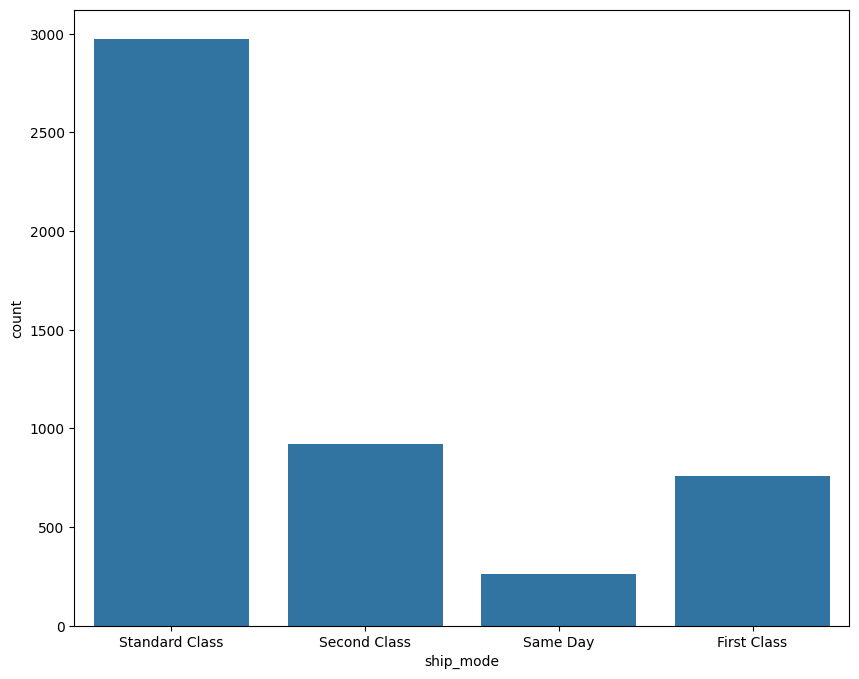

In [80]:
# Setting the figure size
plt.figure(figsize=(10, 8))

# countplot: Show the counts of observations in each categorical bin using bars
sns.countplot(x='ship_mode', data=df)

# Display the figure
plt.show()

WHICH ARE THE MOST PROFITABLE CATEGORY AND SUB-CATEGORY?

In [83]:
# Grouping products by Category and Sub-Category
cat_subcat = pd.DataFrame(data.groupby(['category', 'sub_category'])['profit'].sum())

# Sorting the values
cat_subcat.sort_values(['category','profit'], ascending=False)

profit
category        sub_category             
Technology      Phones        11916.68910
                Accessories    6212.29160
                Machines       3172.03720
                Copiers        1264.54584
Office Supplies Art            5880.10900
                Paper          5708.25170
                Storage        4821.89030
                Binders        4049.18700
                Appliances     3825.70460
                Envelopes      3312.85540
                Supplies       2523.51110
                Labels         1575.95770
                Fasteners      1177.79560
Furniture       Chairs         5493.43370
                Bookcases      3834.19480
                Furnishings    2404.23870
                Tables        -9363.59780